# Project - Part 1

In [1]:
import os
print("Current working directory:",os.getcwd())

import sys
sys.path.append('../../../../CppToPython')

import numpy as np
import GeDiM4Py as gedim

lib = gedim.ImportLibrary("../../../../CppToPython/release/GeDiM4Py.so")
config = { 'GeometricTolerance': 1.0e-8 }
gedim.Initialize(config,lib)

import matplotlib as mlt
import matplotlib.pyplot as plt
from matplotlib import cm

import time

import torch
import torch.nn as nn

# from IPython.display import clear_output
# from IPython.display import display, DisplayHandle

import importlib
import libMOR
importlib.reload(libMOR)

Current working directory: /content/workfolder/LOReduX/Project/Code


<module 'libMOR' from '/content/workfolder/LOReduX/Project/Code/libMOR.py'>

## POD solution

POD is an *explore* and *compress* algorithm based on two different stages:

1. *Explore* the information related to the solution varying with respect to $\boldsymbol \mu$ (*snapshots*) in a finite dimensional set $\mathcal P_{\text{train}} \subset \mathcal P$.
2. *Compress* the redundant information and retain only the most significant "linear directions", building a linear subspace $\mathbb V_N \subset \mathbb V_{N_\delta}$ of dimension $N\ll N_\delta$.

Schematically the analytical solution $u(\boldsymbol\mu)$ is approximated with the FOM solution $u_{N_\delta}$, which is then approximated with a ROM solution $u_N$ using POD:
$$
    u(\boldsymbol\mu)
    \xrightarrow[]{\text{FOM}(\dim=N_\delta)}u_{N_\delta}(\boldsymbol\mu)
    \xrightarrow[\Vert u(\boldsymbol\mu)-u_{N_\delta}(\boldsymbol\mu)\Vert\rightarrow0]{\text{ROM}(\dim=N)}u_N(\boldsymbol\mu).
$$
Consider again the linear system described in Part_0
$$
    \mathbf A\delta\mathbf u\equiv
    (\mathbf A^{\text{Stiff}}+\mu_0\mathbf A^{\text{NL}}(\mu_1))\delta\mathbf u=
    -\mathbf g^{\text{Stiff}}-\frac{\mu_0}{\mu_1}\mathbf g^{\text{NL}}(\mu_1)
    +\mathbf g^{\text{FTg}}+\frac{\mu_0}{\mu_1}\mathbf g^{\text{FTf}}
    \equiv\mathbf f,
$$
and imagine to have already built the reduced space and collected the basis functions $\xi_{i}\in\mathbb R_{N_\delta}$ for $i\in\{1,\dots,N\}$ (i.e. $\mathbb V_N=\text{span}\{\xi_i\}_{i=1}^N$) in a basis matrix 
$$
    \mathbb B=[\xi_1\cdots\xi_N]\in\mathbb R^{N_\delta\times N};
$$ 
intepreting $\mathbb B$ as a linear operator between $\mathbb V_N$ and $\mathbb V_{N_\delta}$, namely $\mathbb B:\mathbb V_N\to\mathbb V_{N_\delta}$, it is then clear that the original linear system can be cast in the low-dimensional in the following manner
$$
    \mathbb B^\top\mathbf A\mathbb B\delta\mathbf u_N\equiv
    (\mathbb B^\top\mathbf A^{\text{Stiff}}\mathbb B+\mu_0\mathbb B^\top\mathbf A^{\text{NL}}(\mu_1)\mathbb B)\delta\mathbf u_N=
    -\mathbb B^\top\mathbf g^{\text{Stiff}}-\frac{\mu_0}{\mu_1}\mathbb B^\top\mathbf g^{\text{NL}}(\mu_1)
    +\mathbb B^\top\mathbf g^{\text{FTg}}+\frac{\mu_0}{\mu_1}\mathbb B^\top\mathbf g^{\text{FTf}}
    \equiv\mathbb B^\top\mathbf f,
$$
where the update must be computed using $\delta\mathbf u=\mathbb B\delta\mathbf u_N$. Two remarks can be made:

1. The affine reduced matrix/vectors can be computed once for every parameter $\boldsymbol\mu\in\mathcal P$.
2. The *non* affine reduced matrix/vectors have to be computed again if the parameter $\boldsymbol\mu\in\mathcal P$ is changed because so does their full counterpart.

The 2. point in a *non* full affine problem, such as this one, makes the plain POD not computationally worthwhile as it will be seen later in the speedup time analysis.

Lastly with $\mathbb B$ the POD method can be visualised using a commutative diagram:
$$
    \begin{CD}
        \mathbb V_{N_\delta} @>\mathbf A\mathbf u=\mathbf f>> \mathbb V_{N_\delta} \\
        @V\mathbb B^\top VV @AA \mathbb BA \\
        \mathbb V_N @>\mathbf A_N\mathbf u_N=\mathbf f_N>> \mathbb V_N
    \end{CD}
$$
in which the hope is that by passing through $\mathbb V_N$ the total computational cost will be less than going directly in $\mathbb V_{N_\delta}$.

### Geometry setup

In [2]:
# Geometry definition
aMax  = 0.0005 # Maximum FE area
L     = 1      # Squre domain length
order = 2      # Order of FE

In [3]:
[dofs, _, _] = libMOR.SetGeometry(aMax,L,order)
Nd = dofs.shape[1]
libMOR.AssembleAffineMatrix1()
[A, _] = libMOR.InnerProductMatrix()

### Snapshot matrix $\mathbb U\in\mathbb R^{M\times N_\delta}$

In [4]:

M = 100 # Number of snapshots [potentially linearly dependent]

# Lists containing two numbers
m0R = [0.1,1] # μ₀ range
m1R = [0.1,1] # μ₁ range

# 2⨯2 Matrix created by the previous two lists
P = np.array([m0R,m1R])

# Definition of the training set
trainSet = np.random.uniform(P[:,0],P[:,1],(M,P.shape[0]))

In [5]:
# Snapshot matrix creation
U = np.zeros((M,Nd))

# Cycles the row of training_set (M⨯2), that is
# all the random parameters generated before
for m in range(M):

	m0 = trainSet[m,0]
	m1 = trainSet[m,1]

	[snapshot, _] = libMOR.FOMSolF1(m0,m1)
	U[m,:] = np.copy(snapshot)

### Basis matrix $\mathbb B$

To build the $N$-dimesional framework, it's necessary to define the correlation snapshot matrix $\mathbf C=\mathbb U\mathbf A\mathbb U^\top\in\mathbb R^{M\times M}$, where $M$ is the cardinality of $\mathcal P_{\text{train}}$ and $\mathbf A$ is the inner product matrix.

By solving the eigenvalue problem $\mathbf C\omega_n=\lambda_n\omega_n$ for $1\leq n\leq M$, with $\Vert\omega_n\Vert_{\mathbb V_{N_\delta}}=1$, it's then possible, due to the definition of correlation matrix (I imagine since $C$ is both symmetric and semidefinite positive), to order all-positive eigenvalues as $\lambda_1\ge\dots\ge\lambda_M\ge0$ and retain the first $N$ eigenpairs $(\lambda_n,\omega_n)$ for $1\leq n\leq N$.

Indeed, defining as $P_N:\mathbb V_{N_\delta}\to\mathbb V_N$ the projector from $\mathbb V_{N_\delta}$ onto $ {\mathbb V}_N$, the following relation holds:
$$
    \sqrt{\sum_{i=1}^M\Vert\mathbf u_{N_\delta}(\boldsymbol\mu_i)-P_N(\mathbf u_{N_\delta}(\boldsymbol{\mu}_i))\Vert_2^2}=
    \sqrt{\sum_{i=N+1}^M\lambda_m},
$$
namely, a fast decay of the eigenvalue magnitude guaratees a good representation of the high-fidelity solution with a few basis functions.

In [6]:
# Create the covariance matrix (An alternative is to use «VM, L, VMt = np.linalg.svd((C))»)
C = U@A@np.transpose(U) # Dimension M⨯M=(M⨯Nδ)⨯(Nδ⨯Nδ)⨯(Nδ⨯M)

# Eigenvalues and eigenvectors
[EigValM, EigVecM]  = np.linalg.eig(C)
EigValN = []
EigVecN = []

# Check which eigenvalues are real to numerical precision
# and then saves them, along with the respective eigenvectors
for e in range(len(EigValM)):

	eigR = EigValM[e].real # Real part of the eigenvalue
	eigC = EigValM[e].imag # Complex part of the eigenvalue

	assert np.isclose(eigC, 0.)
	# The assert statement works like an if structure but it's able to stop
	# the script if the condition is not satisfied by raising an expeption

	EigValN.append(eigR)
	EigVecN.append(EigVecM[e].real)

# Total sum of eigenvalues
totalEnergy = sum(EigValN)

# Cumulative sum of eigenvalues, that is it holds
# retained_energy_vector[1]=eigenvalues[1],
# retained_energy_vector[2]=eigenvalues[1]+eigenvalues[2],
# retained_energy_vector[3]=eigenvalues[1]+eigenvalues[2]+eigenvalues[3],
# and so on; the result is a vector dimensionally similar to eigenvalue
retainedEnergy = np.cumsum(EigValN)

# Relative cumulative sum of eigenvalues
relRetainedEnergy = retainedEnergy/totalEnergy

NewTol = 1. - 1e-7 # Number very close to 1, namely 0.9999999
N_max = 10
N = 0

# Checks which eigenvalues are necessary to have, once summed, a value greater than tol
for v in range(N_max):
	if relRetainedEnergy[v] <= NewTol:
		N += 1
	else:
		exit
# The function np.argmax «returns the indicies of the maximum
# values», so +1 is necessary since the indicies stars at 0

print("The reduced dimension is",N)

The reduced dimension is 2


The basis vectors are obtained by $\xi_n=\chi_n/\Vert\chi_n\Vert_{\mathbb V_{N_\delta}}$ where the $\chi_n$ are the projection of the eigenvectors $\omega_n$ through $\mathbb U^\top$:
$$    
    \chi_n=\mathbb U^\top\omega_n=\sum_{m=1}^M\omega_n^m\mathbf u_{N_\delta}(\boldsymbol\mu_m),
$$
with $1\leq n\leq N$. In this way the projection operator $P_N:\mathbb V_{N_\delta}\to\mathbb V_N$ is defined as
$$
    P_N(\mathbf u_{N_\delta}(\boldsymbol\mu))=\sum_{i=1}^N(\mathbf u_{N_\delta}(\boldsymbol\mu),\xi_n)\xi_n,
$$
or algebraically $\mathbb P_N=\mathbb B\mathbb B^\top$. Lastly it's useful to remember that $\mathbb B=[\xi_1\cdots\xi_N]\in\mathbb R^{N_\delta\times N}$ holds by definition.

In [ ]:
# Create the basis function matrix
B = np.zeros((Nd,N))

for n in range(N):
	eigVec = EigVecN[n]

	basisVec = np.transpose(U)@eigVec
	normVec  = np.sqrt(np.transpose(basisVec)@A@basisVec)
	basisVec /= normVec

	B[:,n] = np.copy(basisVec)

	# «basis = (1/np.sqrt(snapshot_num))*np.transpose(snapshot_matrix)@eigenvector  (This is the one of the book!!)»
	# This is indeed the formula in lecture 4 (Ψₘ=(1/√λₘ)Σ_{k=1}^M[wₖ[αₘ]ₖ]) where «snapshot_num» is the eigenvalue
	# However the most important part is the eigenvector which can then be arbitraly scaled (with √λₘ or its norm)

libMOR.B = B # Copy by reference
libMOR.AssembleReducedAffineMatrix1()

### Speedup analysis

The speedup time is an index that evaluated how many ROM solution it's possible to obtain in the time of a FOM simulation.

In [8]:
T = 100

absErr  = []
relErr  = []
speedUp = []

testSet = np.random.uniform(P[:, 0],P[:, 1],(T,P.shape[0]))

for t in range(T):

    m0 = testSet[t,0]
    m1 = testSet[t,1]
    
    # Full Order Model (FOM)
    startFOM = time.time()
    [u_f, _]  = libMOR.FOMSolF1(m0,m1)
    timeFOM  = time.time() - startFOM

    # Reduced Order Model (ROM)
    startROM = time.time()
    [u_r, _]  = libMOR.ROMSolF1(m0,m1)
    timeROM  = time.time() - startROM
  
    # Speed up time
    speedUp.append(timeFOM/timeROM)
  
    # Absolute error calculations
    errFunction = u_f - u_r
    errNorm = np.sqrt(abs(np.transpose(errFunction)@A@errFunction))
    absErr.append(errNorm)
  
    # Relative error calculations
    FOMNorm = np.sqrt(abs(np.transpose(u_f)@A@u_f))
    errRel  = errNorm/FOMNorm
    relErr.append(errRel)
  
print("avarege relative error = ", np.mean(relErr) )
print("avarege absolute error = ", np.mean(absErr) )
print("avarege speed_up = ", np.mean(speedUp) )

avarege relative error =  0.0008767247605371003
avarege absolute error =  0.00404412530536903
avarege speed_up =  1.224712929913915


## PINN solution

In [2]:
print(torch.__version__) # Checks Pytorch version

if torch.cuda.is_available(): # Checks if the GPU can be used
    print(torch.cuda.get_device_name(0)) # In my case "GeForce GTX 1650"
    device = torch.device("cuda")
else: # If available use the GPU otherwise use the CPU
    device = torch.device("cpu")

libMOR.device = device

2.7.0+cu118
NVIDIA GeForce GTX 1650


### **The loss**

Physics Informed Neural Netwoks (PINN) relates Deep Learning and Partial Differential Equations (PDEs). The main idea is not to purely rely on data, but to exploit the physical model (i.e. the _residual_ of the PDE) in the loss function, which, in more detail, is made by

1. a boundary loss $\text{MSE}_b$ and
2. a residual information $\text{MSE}_r$.

Suppose the physical system to study is described by a PDE of the form $\mathcal R(w(\mathbf x))=0$, then a PINN is a Neural Network $\tilde w$ that minimizes
$$
    \text{MSE}\equiv \text{MSE}_b+\text{MSE}_r,
$$
where
$$ 
    \text{MSE}_b\equiv\frac1{N_b}\sum_{k=1}^{N_b}\vert\tilde w(\mathbf x_k^b)-w(\mathbf x_k^b)\vert^2,
$$
for $\mathbf x_k^b\in\partial\Omega$, while 
$$
    \text{MSE}_r\equiv\frac1{N_r}\sum_{k=1}^{N_r}\vert\mathcal R(\tilde w(\mathbf x_k^r))\vert^2,
$$
for $\mathbf x_k^r\in\Omega$. This is an example of unsupervised learning.

### Model setup

In [3]:
[nNI, nHL, nNH, nNO] = libMOR.SharedPINNStructure()
net = libMOR.PINN(nNI,nHL,nNH,nNO).to(device)
# net = libMOR.PINN(4,3,100,1)

In [4]:
libMOR.ff = libMOR.g1T
seed = 0 # Set a seed for random number generation for reproducibility sake
torch.manual_seed(seed) # Without it, it'd be random every time the code is run

MSELoss   = torch.nn.MSELoss() # Mean squared error loss function
optimiser = torch.optim.Adam(net.parameters()) # 1e-3=0.001 is the default learning rate
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser,factor=0.75,patience=5000)

### Mesh-free approach

In [5]:
# Data from Boundary Conditions (BC) which are datapoints for training
# In this case BC set u=0 in ∂Ω={(x,y)∈Ω=(0,1)² : x=0 ∨ y=0 ∨ x=1 ∨ y=1}
nBP = int(1e4) # Number of random boundary points
nIP = int(1e4) # Number of random internal points

onesBP  = libMOR.HomogenousTensor(nBP,1)
zerosBP = libMOR.HomogenousTensor(nBP,0)
zerosIP = libMOR.HomogenousTensor(nIP,0)
# Homogenous null tensor to evaluate the euclidian norm of the residual;
# indeed this is done by subtractig zero in the MSE loss function

In [6]:
# Training phase
l = 1 # Lambda to balance the losses

tol   = 1e-7
nEMax = int(5e5) # Number of maximum epochs
e     = 0
loss  = torch.tensor(1)

step   = int(1e2)
logger = libMOR.LoggerPINN(optimiser,step)

In [9]:
net.train()

while loss.item() >= tol and e <= nEMax: # and optimiser.param_groups[0]['lr']>1e-7
    optimiser.zero_grad() # Set the gradients to zero

    # BC Loss
    mseBC = libMOR.lossBC(net,MSELoss,nBP,zerosBP,onesBP)

    # PDE Loss
    mseRes = libMOR.lossRes(net,MSELoss,nIP,zerosIP)

    # Total loss
    [loss, l] = libMOR.lossTot(mseBC,mseRes,l)

    loss.backward()  # Backpropagation
    # if e > 1e4:
    #     torch.nn.utils.clip_grad_norm_(net.parameters(),max_norm=5e1)
    optimiser.step() # Optimiser update
    
    scheduler.step(loss.item()) # Scheduler check

    logger.log(e,step,mseBC,mseRes,loss,l,net)

    e += 1

300100	meanL: 2.7723e-05	meanBC: 4.204629e-06	meanRes: 4.745649e-04	lr: 1e-05	λ: 0.95	Grad: 0.14
300200	meanL: 2.7200e-05	meanBC: 4.206616e-06	meanRes: 4.640691e-04	lr: 1e-05	λ: 0.95	Grad: 0.12
300300	meanL: 2.7018e-05	meanBC: 4.211269e-06	meanRes: 4.603504e-04	lr: 1e-05	λ: 0.95	Grad: 0.10
300400	meanL: 2.7686e-05	meanBC: 4.214304e-06	meanRes: 4.736573e-04	lr: 1e-05	λ: 0.95	Grad: 0.14
300500	meanL: 2.7372e-05	meanBC: 4.188546e-06	meanRes: 4.678593e-04	lr: 1e-05	λ: 0.95	Grad: 0.14
300600	meanL: 2.7111e-05	meanBC: 4.191901e-06	meanRes: 4.625664e-04	lr: 1e-05	λ: 0.95	Grad: 0.10
300700	meanL: 2.7089e-05	meanBC: 4.190471e-06	meanRes: 4.621517e-04	lr: 1e-05	λ: 0.95	Grad: 0.11
300800	meanL: 2.7272e-05	meanBC: 4.186990e-06	meanRes: 4.658910e-04	lr: 1e-05	λ: 0.95	Grad: 0.13
300900	meanL: 2.7619e-05	meanBC: 4.194163e-06	meanRes: 4.726921e-04	lr: 1e-05	λ: 0.95	Grad: 0.14
301000	meanL: 2.7230e-05	meanBC: 4.188897e-06	meanRes: 4.650011e-04	lr: 1e-05	λ: 0.95	Grad: 0.13
301100	meanL: 2.7491e-05	meanB

### PINN/FOM example

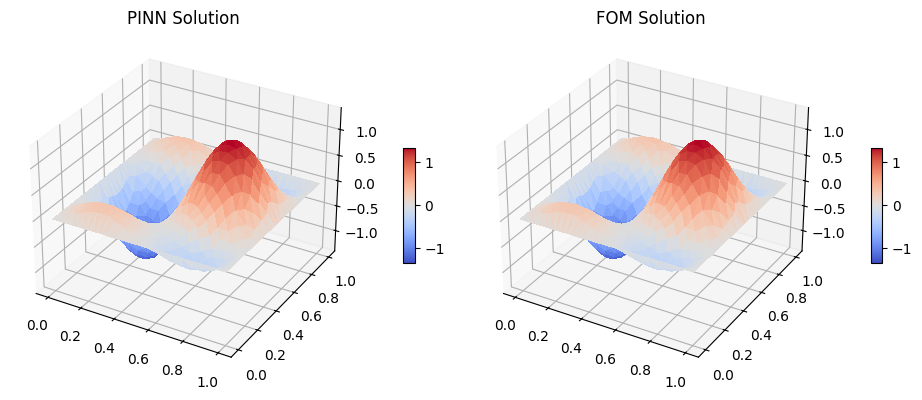

In [8]:
# Parameters
m0 = .45
m1 = .45

# Figure
fig = plt.figure(figsize=(12,5))
ax1 = fig.add_subplot(1,2,1,projection='3d')
ax2 = fig.add_subplot(1,2,2,projection='3d')
plt.subplots_adjust(wspace=0.01)

# Geometry
[dofs, strongs, mesh] = libMOR.SetGeometry(0.005,1,2)
x = np.concatenate((dofs[0,:],strongs[0,:]),axis=0)
y = np.concatenate((dofs[1,:],strongs[1,:]),axis=0)
triang = mlt.tri.Triangulation(x,y)


# PINN solution
[u, u_strong] = libMOR.buildSolPINN(net,m0,m1)
z = np.concatenate((u,u_strong), axis=0)

surf = ax1.plot_trisurf(x,y,z,triangles=triang.triangles, \
                        cmap=cm.coolwarm,linewidth=0,antialiased=False)
fig.colorbar(surf,shrink=0.3,aspect=10,pad=0.1)
ax1.set_title("PINN Solution")


# FOM solution
libMOR.AssembleAffineMatrix1()
[u, u_strong] = libMOR.FOMSolF1(m0,m1)
z = np.concatenate((u,u_strong), axis=0)

surf = ax2.plot_trisurf(x,y,z,triangles=triang.triangles, \
                        cmap=cm.coolwarm,linewidth=0,antialiased=False)
fig.colorbar(surf,shrink=0.3,aspect=10,pad=0.1)
ax2.set_title("FOM Solution")


plt.show()


### Saving/Loading

In [15]:
# Save the model
torch.save({
            'modelStateDict': net.state_dict(),
            'optimiserStateDict': optimiser.state_dict(),
            'schedulerStateDict': scheduler.state_dict(),
            'loss': loss.item(),
            'structure': [nNI,nHL,nNH,nNO],
            'lastLog': logger.last,
            },'PINN1.pth')

In [7]:
# Load the model
PINN1 = torch.load('PINN1.pth')

net.load_state_dict(PINN1['modelStateDict'])
optimiser.load_state_dict(PINN1['optimiserStateDict'])
scheduler.load_state_dict(PINN1['schedulerStateDict'])
loss = torch.tensor(PINN1['loss'])

# The model has to be loaded after all the previous variables have
# been defined, that is before the for loop in the training phase

### Speedup analysis

In [10]:
# Geometry definition
aMax  = 0.001 # Maximum mesh area
L     = 1    # Squre domain length
order = 2    # Order of FE

libMOR.SetGeometry(aMax,L,order)
libMOR.AssembleAffineMatrix1()
[A, A_strong] = libMOR.InnerProductMatrix()

In [11]:
T = 100

absErr  = []
relErr  = []
speedUp = []

# Lists containing two numbers
m0R = [0.1,1] # μ₀ range
m1R = [0.1,1] # μ₁ range

# 2⨯2 Matrix created by the previous two lists
P = np.array([m0R,m1R])

testSet = np.random.uniform(low=P[:, 0], \
                            high=P[:, 1], \
                            size=(T, P.shape[0]))

net.eval()

print("Computing error and speedup analysis")

for t in range(T):

    m0 = testSet[t,0]
    m1 = testSet[t,1]
    
        # Full Order Model (FOM) solution
    startFOM = time.time()
    [u_f, u_strong] = libMOR.FOMSolF1(m0,m1)
    timeFOM  = time.time() - startFOM

        # Reduced Order Model (ROM) solution
    startROM = time.time()
    [u_n, u_strongn] = libMOR.buildSolPINN(net,m0,m1)
    timeROM  = time.time() - startROM
  
        # Speed up time
    speedUp.append(timeFOM/timeROM)
  
        # Absolute error calculations
    errFunctionDofs   = u_f - u_n
    errFunctionStrong = u_strong - u_strongn
    errNorm = np.sqrt(abs(np.transpose(errFunctionDofs)@A@errFunctionDofs) + \
                      abs(np.transpose(A_strong@errFunctionStrong)@A@A_strong@errFunctionStrong))
    absErr.append(errNorm)
  
        # Relative error calculations
    FOMNorm = np.sqrt(abs(np.transpose(u_f)@A@u_f))
    errRel  = errNorm/FOMNorm
    relErr.append(errRel)
  
print("avarege relative error = ",np.mean(relErr))
print("avarege absolute error = ",np.mean(absErr))
print("avarege speed_up = ",np.mean(speedUp))

Computing error and speedup analysis
avarege relative error =  0.008442556685131301
avarege absolute error =  0.038951374501479626
avarege speed_up =  70.32656368677692


## POD-NN solution

POD-NN is a strategy that allows not to rely on affinity of the problem with respect of the parameters; its algorithm, given $\mu\in\mathcal P_{\text{train}}$, relies on two stages:

1. a POD stage where the basis matrix $\mathbb B$ is built and the FOM solutions (snapshots) $\mathbf u_{N_\delta}(\mu)$ are calculated and
2. a Neural Network stage where a Feed-Forward Neural Network (FFNN) is trained to predict the reduced snapshot $\mathbf u_{R_\delta}(\mu)$ such that $\mathbb B\mathbf u_{R_\delta}(\boldsymbol\mu)=\mathbf u_{\delta}(\boldsymbol\mu)\approx\mathbf u_{N_\delta}(\boldsymbol\mu)$.

In this way the most disadvantageous part of POD for a *non* affine problem, i.e. the reduction of the matricies/vectors involved in the linear system, is skipped using the FFNN.

It's the best of both worlds as the speedup time is guaranteed while still having accurate solutions. Schematically the POD commutative diagram
$$
    \begin{CD}
        \mathbb V_{N_\delta} @>\mathbf A\mathbf u=\mathbf f>> \mathbb V_{N_\delta} \\
        @V\mathbb B^\top VV @AA \mathbb BA \\
        \mathbb V_N @>\mathbf A_N\mathbf u_N=\mathbf f_N>> \mathbb V_N
    \end{CD}
$$
becomes

<div style="text-align: center;"><img src="../Figures/Commutative_Diagram_PODNN.png" alt="Example Image" width="200"/></div>

This is an example of supervised learning.

### POD setup

In [31]:
# Geometry definition
aMax  = 0.001 # Maximum mesh area
L     = 1    # Squre domain length
order = 2    # Order of FE

In [32]:
[dofs, strongs, mesh] = libMOR.SetGeometry(aMax,L,order)
Nd = dofs.shape[1]
libMOR.AssembleAffineMatrix1()
[A, _] = libMOR.InnerProductMatrix()

In [33]:
M = 100 # Number of snapshots [potentially linearly dependent]

# Lists containing two numbers
m0R = [0.1,1] # μ₀ range
m1R = [0.1,1] # μ₁ range

# 2⨯2 Matrix created by the previous two lists
P = np.array([m0R,m1R])

# Definition of the training set
trainSet = np.random.uniform(P[:,0],P[:,1],(M,P.shape[0]))

In [34]:
# Snapshot matrix creation
U = np.zeros((M,Nd))

# Cycles the row of training_set (M⨯2), that is
# all the random parameters generated before
for m in range(M):

	m0 = trainSet[m,0]
	m1 = trainSet[m,1]

	[snapshot, _] = libMOR.FOMSolF1(m0,m1)
	U[m,:] = np.copy(snapshot)

In [35]:
# Create the covariance matrix (An alternative is to use «VM, L, VMt = np.linalg.svd((C))»)
C = U@A@np.transpose(U) # Dimension M⨯M=(M⨯Nδ)⨯(Nδ⨯Nδ)⨯(Nδ⨯M)

# Eigenvalues and eigenvectors
[EigValM, EigVecM]  = np.linalg.eig(C)
EigValN = []
EigVecN = []

# Check which eigenvalues are real to numerical precision
# and then saves them, along with the respective eigenvectors
for e in range(len(EigValM)):

	eigR = EigValM[e].real # Real part of the eigenvalue
	eigC = EigValM[e].imag # Complex part of the eigenvalue

	assert np.isclose(eigC, 0.)
	# The assert statement works like an if structure but it's able to stop
	# the script if the condition is not satisfied by raising an expeption

	EigValN.append(eigR)
	EigVecN.append(EigVecM[e].real)

# Total sum of eigenvalues
totalEnergy = sum(EigValN)

# Cumulative sum of eigenvalues, that is it holds
# retained_energy_vector[1]=eigenvalues[1],
# retained_energy_vector[2]=eigenvalues[1]+eigenvalues[2],
# retained_energy_vector[3]=eigenvalues[1]+eigenvalues[2]+eigenvalues[3],
# and so on; the result is a vector dimensionally similar to eigenvalue
retainedEnergy = np.cumsum(EigValN)

# Relative cumulative sum of eigenvalues
relRetainedEnergy = retainedEnergy/totalEnergy

NewTol = 1. - 1e-7 # Number very close to 1, namely 0.9999999
N_max = 10
N = 0

# Checks which eigenvalues are necessary to have, once summed, a value greater than tol
for v in range(N_max):
	if relRetainedEnergy[v] <= NewTol:
		N += 1
	else:
		exit
# The function np.argmax «returns the indicies of the maximum
# values», so +1 is necessary since the indicies stars at 0

print("The reduced dimension is ",N)

The reduced dimension is  2


In [ ]:
# Create the basis function matrix
B = np.zeros((Nd,N))

for n in range(N):
	eigVec = EigVecN[n]

	basisVec = np.transpose(U)@eigVec
	normVec  = np.sqrt(np.transpose(basisVec)@A@basisVec)
	basisVec /= normVec

	B[:,n] = np.copy(basisVec)

	# «basis = (1/np.sqrt(snapshot_num))*np.transpose(snapshot_matrix)@eigenvector  (This is the one of the book!!)»
	# This is indeed the formula in lecture 4 (Ψₘ=(1/√λₘ)Σ_{k=1}^M[wₖ[αₘ]ₖ]) where «snapshot_num» is the eigenvalue
	# However the most important part is the eigenvector which can then be arbitraly scaled (with √λₘ or its norm)

libMOR.B = B # Copy by reference
libMOR.AssembleReducedAffineMatrix1()

### NN training

In [ ]:
print(torch.__version__) # Checks Pytorch version

if torch.cuda.is_available(): # Checks if the GPU can be used
    print(torch.cuda.get_device_name(0)) # In my case "GeForce GTX 1650"
    device = torch.device("cuda")
else: # If available use the GPU otherwise use the CPU
    device = torch.device("cpu")

libMOR.device = device

2.7.0+cu118
NVIDIA GeForce GTX 1650


In [38]:
# The inputs are the two parameters (μ₀,μ₁)
nNI = P.shape[0]  # Number of input nodes

nHL = 3 # Number of hidden layers
nNH = 30 # Number of hidden nodes per layer

# The outputs are the components of the reduced space basis
nNO = N  # Number of output nodes

In [ ]:
seed_num = 31
torch.manual_seed(seed_num)
net = libMOR.PODNN(nNI,nHL,nNH,nNO).to(device)

MSELoss = nn.MSELoss()
optimiser = torch.optim.Adam(net.parameters(),lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser,factor=0.75,patience=100)

Now the outputs to train the NN need to be calculated and, as stated before, by definition it holds
$$
    \mathbb B\mathbf u_{R_\delta}(\boldsymbol\mu)=\mathbf u_{\delta}(\boldsymbol\mu),
$$
where $\mathbf u_{\delta}(\boldsymbol\mu)$ is the reduced vector related to the Galerkin projector of the snapshot $\mathbf u_{N_\delta}(\boldsymbol\mu)$, i.e. the best approximation of $u_{N_\delta}$ in $\mathbb V_N$ with respect to the inner-product defined by the matrix $\mathbf A_\delta$; mathematically one has
$$
    \mathbf u_{\delta}(\boldsymbol\mu)=\mathbb P^{\boldsymbol\mu}\mathbf u_{N_\delta}(\boldsymbol\mu)
$$
with
$$
    \mathbb P^{\boldsymbol\mu}\equiv
    \mathbb B(\mathbb B^\top\mathbf A_\delta\mathbb B)^{-1}\mathbb B^\top\mathbf A_\delta=
    \mathbb B(\mathbf A_N)^{-1}\mathbb B^\top\mathbf A_\delta
$$
being the projector from $\mathbb V_{N_\delta}$ to $\mathbb V_N$; thus it holds that
$$
    \mathbb B\mathbf u_{R_\delta}(\boldsymbol\mu)=\mathbb P^{\boldsymbol\mu}\mathbf u_{N_\delta}(\boldsymbol\mu).
$$
By expanding $\mathbb P^{\boldsymbol\mu}$ one has
$$
    \mathbb B\mathbf u_{R_\delta}(\boldsymbol\mu)=\mathbf A_N^{-1}\mathbb B^\top\mathbf A_\delta\mathbf u_{N_\delta}(\boldsymbol\mu),
$$
where, instead of computing the inverse of $\mathbf A_N$, it's better to solve the linear system
$$
    \mathbf A_N\mathbf u_{R_\delta}(\boldsymbol\mu)=\mathbb B^\top\mathbf A_\delta\mathbf u_{N_\delta}(\boldsymbol\mu)\equiv\mathbf f_N
$$
with which the reduced projections $\mathbf u_{R_\delta}(\boldsymbol\mu)$ are found for each snapshot. In essence the FFNN $\boldsymbol\pi(\boldsymbol\mu)$ has to be trained such that
$$
    \boldsymbol\pi(\boldsymbol\mu)=\mathbf u_{R_\delta}(\boldsymbol\mu),
$$
i.e. the inputs are the parameters of the training set and the output is the Galerkin projection of the snapshots of the training set; in this way the vector of the reduced solution related to the parameter $\boldsymbol\mu$ is calculated *without solving the reduced system*.

In [ ]:
# Training set
An = np.transpose(B)@A@B

m0 = torch.from_numpy(trainSet[:,0].reshape(-1,1)).float().to(device)
m1 = torch.from_numpy(trainSet[:,1].reshape(-1,1)).float().to(device)

output = []

for i in range(U.shape[0]):
  
    snapshot = U[i]
  
    snapshotP = np.linalg.solve(An,np.transpose(B)@A@snapshot)
  
    output.append(snapshotP)

output = np.array(output)
output = torch.from_numpy(output).float().to(device)

In [41]:
tol   = 1e-7
nEMax = int(1e5)  # Number of maximum epochs
e     = 0

loss   = torch.tensor(1)
step   = int(1e2)
logger = libMOR.LoggerPODNN(optimiser,step)

In [ ]:
net.train()

while loss.item() >= tol and e <= nEMax:
    optimiser.zero_grad() # Set the gradients to zero
            
    output = net(m0,m1) # Compute output
    
    loss = MSELoss(output,output)

    loss.backward() # Backpropagation
    optimiser.step()    # Optimiser update

    logger.log(e,step,loss,net)

    e += 1

0	meanL: 7.8116e-02	lr: 1e-05	Grad: 0.07
100	meanL: 2.1865e+00	lr: 1e-03	Grad: 3.20
200	meanL: 7.3729e-01	lr: 1e-03	Grad: 0.04
300	meanL: 6.8402e-01	lr: 1e-03	Grad: 0.27
400	meanL: 9.6613e-02	lr: 1e-03	Grad: 0.36
500	meanL: 1.1588e-02	lr: 1e-03	Grad: 0.05
600	meanL: 4.9176e-03	lr: 1e-03	Grad: 0.03
700	meanL: 2.0368e-03	lr: 1e-03	Grad: 0.02
800	meanL: 9.8476e-04	lr: 1e-03	Grad: 0.01
900	meanL: 5.8905e-04	lr: 1e-03	Grad: 0.01
1000	meanL: 4.2064e-04	lr: 1e-03	Grad: 0.01
1100	meanL: 3.3767e-04	lr: 1e-03	Grad: 0.00
1200	meanL: 2.8714e-04	lr: 1e-03	Grad: 0.00
1300	meanL: 2.4984e-04	lr: 1e-03	Grad: 0.00
1400	meanL: 2.1923e-04	lr: 1e-03	Grad: 0.00
1500	meanL: 1.9303e-04	lr: 1e-03	Grad: 0.00
1600	meanL: 1.7021e-04	lr: 1e-03	Grad: 0.00
1700	meanL: 1.5020e-04	lr: 1e-03	Grad: 0.00
1800	meanL: 1.3259e-04	lr: 1e-03	Grad: 0.00
1900	meanL: 1.1707e-04	lr: 1e-03	Grad: 0.00
2000	meanL: 1.0338e-04	lr: 1e-03	Grad: 0.00
2100	meanL: 9.1333e-05	lr: 1e-03	Grad: 0.00
2200	meanL: 8.0734e-05	lr: 1e-03	Grad: 0.00


KeyboardInterrupt: 

### POD-NN/FOM example

In [43]:
m0 = .45
m1 = .45

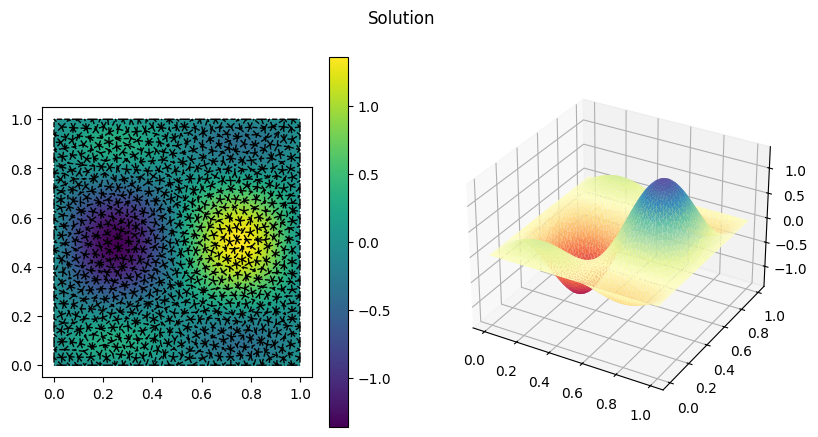

In [44]:
# Full solution
[FOMSol, FOMSolStrong] = libMOR.FOMSolF1(m0,m1)
gedim.PlotSolution(mesh,dofs,strongs,FOMSol,FOMSolStrong)

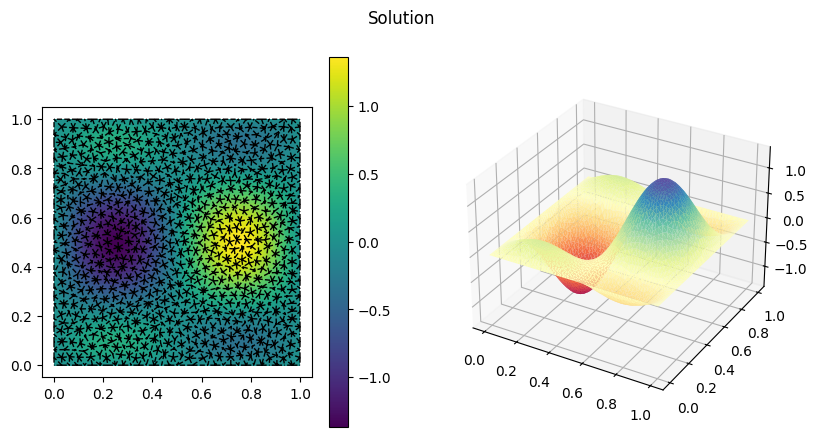

In [45]:
# Reduced solution
ROMsolN = libMOR.buildSolPODNN(net,m0,m1)
ROMSol = B@ROMsolN
gedim.PlotSolution(mesh,dofs,strongs,ROMSol,FOMSolStrong)

### Speedup Analysis

In [ ]:
T = 100

absErr  = []
relErr  = []
speedUp = []

testSet = np.random.uniform(P[:,0],P[:,1],(T, P.shape[0]))

net.eval()

for t in range(T):

    m0 = testSet[t,0]
    m1 = testSet[t,1]
    
        # Full Order Model (FOM) solution
    startFOM = time.time()
    [u_f, _]  = libMOR.FOMSolF1(m0,m1)
    timeFOM  = time.time() - startFOM

        # Reduced Order Model (ROM) solution
    mu = [[m0,m1]]
    mu = np.float32(mu)
    mu = torch.tensor(mu)

    startROM = time.time()
    u_r = libMOR.buildSolPODNN(net,m0,m1)
    u_n = B@u_r
    timeROM  = time.time() - startROM
  
        # Speed up time
    speedUp.append(timeFOM/timeROM)
  
        # Absolute error calculations
    errFunction = u_f - u_n
    errNorm = np.sqrt(abs(np.transpose(errFunction)@A@errFunction))
    absErr.append(errNorm)
  
        # Relative error calculations
    FOMNorm = np.sqrt(abs(np.transpose(u_f)@A@u_f))
    errRel  = errNorm/FOMNorm
    relErr.append(errRel)
  
print("avarege relative error = ", np.mean(relErr) )
print("avarege absolute error = ", np.mean(absErr) )
print("avarege speed_up = ", np.mean(speedUp) )

avarege relative error =  0.0012669702777223046
avarege absolute error =  0.005842837821972214
avarege speed_up =  296.37237355835373
